# 03 - BAF Predictive Model Benchmarks

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

if KAGGLE:
    os.environ["THESIS_QUICK_RUN"] = "0"
    os.environ["THESIS_SYNTHETIC_FALLBACK"] = "0"
    if not KAGGLE_PROJECT_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(KAGGLE_PROJECT_DIR)],
            check=True,
        )

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = [path for path in base.glob("**/configs") if path.is_dir()]
            if matches:
                return matches[0].parent
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "0") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "0") == "1"
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"
INPUT_ROOTS = [OUTPUT_BASE, PROJECT_ROOT / "results/runs/notebooks"]
if Path("/kaggle/input").exists():
    INPUT_ROOTS.append(Path("/kaggle/input"))

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    GIT_COMMIT = None

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "synthetic_fallback": ALLOW_SYNTHETIC_FALLBACK,
    "kaggle": KAGGLE,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': 'f30635ece025de6643fa50263565b4b1a2ccda24', 'quick_run': False, 'synthetic_fallback': False, 'kaggle': True}


## Thiết lập

PR-AUC là metric xếp hạng chính. Mỗi full run dùng ba seeds. Calibration được fit trên nửa đầu
validation, chọn trên nửa sau validation; decision threshold cũng chỉ chọn trên nửa sau validation.
Reference predictor được chọn bằng mean validation raw PR-AUC, không dùng test.

In [2]:
from src.experiment import run_repeated_predictive_benchmarks

output_dir = OUTPUT_BASE / "03_baf_model_benchmarks"
result = run_repeated_predictive_benchmarks(
    PROJECT_ROOT / "configs/baf.yaml",
    output_dir=output_dir,
    model_names=("mlp", "tabular_resnet", "tree"),
    quick_run=QUICK_RUN,
    synthetic_fallback=ALLOW_SYNTHETIC_FALLBACK,
)
summary = result["summary"]
print({
    "data_sources": result["data_sources"],
    "seeds": result["seeds"],
    "reference_model_key": result["reference_model_key"],
    "reference_seed": result["reference_seed"],
    "frozen_manifest": str(result["frozen_manifest_path"]),
})
display(summary.round(4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

{'data_sources': ['real'], 'seeds': [42, 123, 2026], 'reference_model_key': 'tree', 'reference_seed': 42, 'frozen_manifest': '/kaggle/working/thesis_outputs/03_baf_model_benchmarks/frozen_reference_manifest.json'}


,model,model_key,split,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fbeta_mean,fbeta_std,brier_mean,brier_std,ece_mean,ece_std,nll_mean,nll_std,threshold_mean,threshold_std,positive_rate_mean,positive_rate_std,raw_pr_auc_mean,raw_pr_auc_std,raw_roc_auc_mean,raw_roc_auc_std,n_seeds
0,MLP,mlp,test,0.1403,0.0054,0.8723,0.0007,0.1499,0.0126,0.4026,0.0281,0.2178,0.0098,0.3000,0.0025,0.0128,0.0,0.0022,0.0003,0.0582,0.0003,0.0737,0.0115,0.0380,0.0060,0.1546,0.0034,0.8733,0.0005,3
1,MLP,mlp,validation,0.1447,0.0034,0.8775,0.0009,0.1401,0.0128,0.4257,0.0278,0.2102,0.0114,0.3012,0.0029,0.0107,0.0,0.0006,0.0000,0.0492,0.0001,0.0737,0.0115,0.0363,0.0058,0.1548,0.0015,0.8765,0.0009,3
2,TabularResNet,tabular_resnet,test,0.1260,0.0028,0.8615,0.0040,0.1354,0.0088,0.3994,0.0322,0.2017,0.0060,0.2864,0.0062,0.0129,0.0,0.0022,0.0003,0.0596,0.0006,0.0698,0.0057,0.0417,0.0060,0.1369,0.0027,0.8624,0.0039,3
3,TabularResNet,tabular_resnet,validation,0.1307,0.0035,0.8653,0.0051,0.1233,0.0064,0.4335,0.0173,0.1918,0.0059,0.2880,0.0012,0.0108,0.0,0.0006,0.0000,0.0505,0.0003,0.0698,0.0057,0.0417,0.0037,0.1389,0.0022,0.8642,0.0049,3
4,lightgbm,tree,test,0.1736,0.0009,0.8893,0.0015,0.1725,0.0086,0.4368,0.0264,0.2469,0.0044,0.3336,0.0062,0.0125,0.0,0.0026,0.0004,0.0559,0.0003,0.0750,0.0119,0.0357,0.0039,0.1890,0.0019,0.8906,0.0007,3
5,lightgbm,tree,validation,0.1797,0.0030,0.8962,0.0015,0.1559,0.0081,0.4455,0.0148,0.2308,0.0069,0.3245,0.0019,0.0104,0.0,0.0005,0.0000,0.0470,0.0001,0.0750,0.0119,0.0339,0.0028,0.1899,0.0019,0.8956,0.0010,3


## Data and calibration

In [3]:
display(result["data_summary"])
selected_calibration = result["calibration_comparison"].query("selected").copy()
display(selected_calibration.round(5))
display(result["predictive_bootstrap"].round(5))

,split,rows,time_min,time_max,time_group_count,time_groups,overlap_groups,group_disjoint,fraud_rate
0,train,675666,0,4,5,"[0, 1, 2, 3, 4]",[],True,0.009975
1,validation,119323,5,5,1,[5],[],True,0.011825
2,test,205011,6,7,2,"[6, 7]",[],True,0.014038


,seed,model,model_key,method,brier,ece,nll,fit_rows,selection_rows,selected
2,42,MLP,mlp,isotonic,0.01046,0.00121,0.04913,59661.0,59662.0,True
5,42,TabularResNet,tabular_resnet,isotonic,0.01055,0.00114,0.05001,59661.0,59662.0,True
8,42,lightgbm,tree,isotonic,0.01023,0.00093,0.04630,59661.0,59662.0,True
11,123,MLP,mlp,isotonic,0.01046,0.00125,0.04865,59661.0,59662.0,True
14,123,TabularResNet,tabular_resnet,isotonic,0.01053,0.00118,0.04964,59661.0,59662.0,True
17,123,lightgbm,tree,isotonic,0.01026,0.00090,0.04663,59661.0,59662.0,True
20,2026,MLP,mlp,isotonic,0.01050,0.00133,0.04873,59661.0,59662.0,True
23,2026,TabularResNet,tabular_resnet,isotonic,0.01057,0.00107,0.05059,59661.0,59662.0,True
26,2026,lightgbm,tree,isotonic,0.01026,0.00093,0.04676,59661.0,59662.0,True


,reference_model_key,comparator_model_key,observed_difference,bootstrap_mean_difference,ci_low,ci_high,probability_a_better,bootstrap_iterations,bootstrap_rows
0,tree,mlp,0.03507,0.03479,0.02608,0.04289,1.0,300.0,205011.0
1,tree,tabular_resnet,0.05239,0.05211,0.04273,0.06057,1.0,300.0,205011.0


## Results

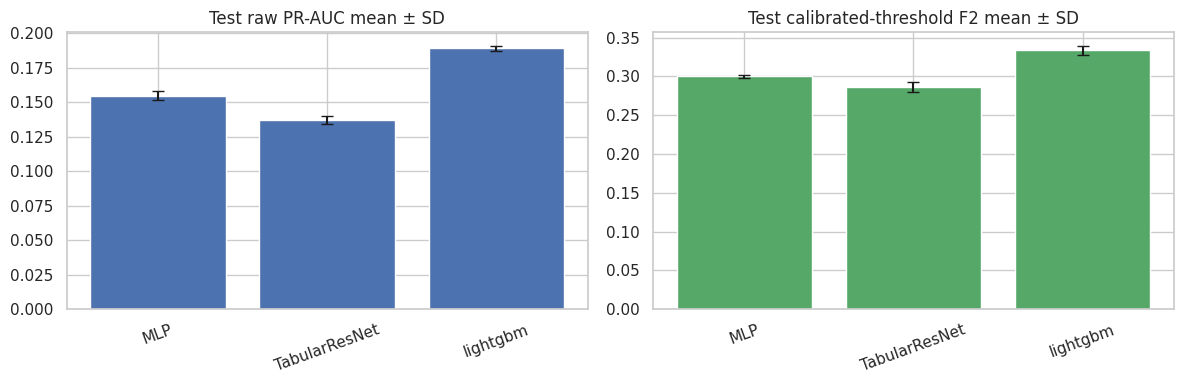

In [4]:
test_metrics = summary.query("split == 'test'").copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(test_metrics["model"], test_metrics["raw_pr_auc_mean"],
            yerr=test_metrics["raw_pr_auc_std"].fillna(0), color="#4C72B0", capsize=4)
axes[0].set_title("Test raw PR-AUC mean ± SD")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(test_metrics["model"], test_metrics["fbeta_mean"],
            yerr=test_metrics["fbeta_std"].fillna(0), color="#55A868", capsize=4)
axes[1].set_title("Test calibrated-threshold F2 mean ± SD")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(output_dir / "predictive_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

In [5]:
history_rows = []
for seed, model_histories in result["histories"].items():
    for model_name, history in model_histories.items():
        history_frame = pd.DataFrame(history)
        best_index = history_frame["validation_pr_auc"].idxmax()
        history_rows.append({
            "seed": seed, "model": model_name, "epochs_run": len(history_frame),
            "best_epoch": int(history_frame.loc[best_index, "epoch"]),
            "best_validation_pr_auc": history_frame.loc[best_index, "validation_pr_auc"],
        })
display(pd.DataFrame(history_rows).round(5))

,seed,model,epochs_run,best_epoch,best_validation_pr_auc
0,42,mlp,74,59,0.15632
1,42,tabular_resnet,40,20,0.13898
2,123,mlp,73,58,0.15338
3,123,tabular_resnet,43,23,0.14117
4,2026,mlp,62,47,0.15469
5,2026,tabular_resnet,47,27,0.13670


## Takeaways

In [6]:
selected_key = result["reference_model_key"]
validation_best = summary.query("split == 'validation' and model_key == @selected_key").iloc[0]
test_reference = summary.query("split == 'test' and model_key == @selected_key").iloc[0]
display(Markdown(
    f"- Reference model selected on validation: **{validation_best['model']}**.\n"
    f"- Mean validation raw PR-AUC: **{validation_best['raw_pr_auc_mean']:.4f}**.\n"
    f"- Locked test raw PR-AUC: **{test_reference['raw_pr_auc_mean']:.4f} ± {test_reference['raw_pr_auc_std']:.4f}**.\n"
    f"- Frozen reference seed: **{result['reference_seed']}**.\n"
    "- Test metrics report the locked protocol; they are not used for model, calibration, or threshold selection."
))

- Reference model selected on validation: **lightgbm**.
- Mean validation raw PR-AUC: **0.1899**.
- Locked test raw PR-AUC: **0.1890 ± 0.0019**.
- Frozen reference seed: **42**.
- Test metrics report the locked protocol; they are not used for model, calibration, or threshold selection.